In [ ]:
# !pip install -r requirements.txt

In [48]:
from typing import Optional
import numpy as np

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import torchaudio
from torchaudio.datasets import SPEECHCOMMANDS
from torchaudio import functional as F

from tqdm.notebook import tqdm
from thop import profile
import time
import matplotlib.pyplot as plt
import os

In [3]:
random_state = 42
batch_size = 32
torch.manual_seed(random_state)
torch.cuda.manual_seed(random_state)
np.random.seed(random_state)
to_download = True
data_path = ''
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Log-Mel Filter Banks

In [4]:
class LogMelFilterBanks(nn.Module):
  def __init__(
          self,
          n_fft: int = 400,
          samplerate: int = 16000,
          hop_length: int = 160,
          n_mels: int = 80,
          pad_mode: str = 'reflect',
          power: float = 2.0,
          normalize_stft: bool = False,
          onesided: bool = True,
          center: bool = True,
          return_complex: bool = True,
          f_min_hz: float = 0.0,
          f_max_hz: Optional[float] = None,
          norm_mel: Optional[str] = None,
          mel_scale: str = 'htk'
      ):
      super(LogMelFilterBanks, self).__init__()
      # general params and params defined by the exercise
      self.n_fft = n_fft
      self.window_length = n_fft
      self.window = torch.hann_window(self.window_length).to(device)
      self.power = power
      self.return_complex = return_complex

      self.f_min_hz = f_min_hz
      self.f_max_hz = f_max_hz if f_max_hz is not None else float(samplerate // 2)
      self.n_mels = n_mels
      self.samplerate = samplerate
      self.norm_mel = norm_mel
      self.mel_scale = mel_scale


      self.hop_length = hop_length
      self.center = center
      self.pad_mode = pad_mode
      self.normalize_stft = normalize_stft
      self.onesided = onesided

      self.mel_fbanks = self._init_melscale_fbanks().to(device)

  def _init_melscale_fbanks(self):
    return F.melscale_fbanks(
        # Turns a normal STFT into a mel frequency STFT with triangular filter banks
        n_freqs=(self.n_fft // 2) + 1,
        f_min=self.f_min_hz,
        f_max=self.f_max_hz,
        n_mels=self.n_mels,
        sample_rate=self.samplerate,
        norm=self.norm_mel,
        mel_scale = self.mel_scale
    )

  def spectrogram(self, x):
    # x - is an input signal
    return torch.stft(
        input=x,
        n_fft=self.n_fft,
        hop_length=self.hop_length,
        win_length=self.window_length,
        window=self.window,
        center=self.center,
        pad_mode=self.pad_mode,
        normalized=self.normalize_stft,
        onesided=self.onesided,
        return_complex=self.return_complex
    )

  def forward(self, x):
    """
    Args:
        x (Torch.Tensor): Tensor of audio of dimension (batch, time), audiosignal
    Returns:
        Torch.Tensor: Tensor of log mel filterbanks of dimension (batch, n_mels, n_frames),
            where n_frames is a function of the window_length, hop_length and length of audio
    """
    spectr = self.spectrogram(x)

    power_spectr = spectr.abs().pow(self.power)

    mel_spec = torch.matmul(power_spectr.transpose(-1, -2), self.mel_fbanks).transpose(-1, -2)

    log_mel_spec = torch.log(mel_spec + 1e-6)

    return log_mel_spec

# Castom DataSet

In [5]:
class BinarySpeechDataset(Dataset):
  def __init__(self, data_path, download=to_download, subset='training'):
    self.dataset = SPEECHCOMMANDS(root=data_path, download=download, subset=subset)
    all_files = self.dataset._walker
    self.filtered_files = [
        f for f in all_files
        if os.path.basename(os.path.dirname(f)) in ['yes', 'no']
    ]
    self.label_map = {'no': 0, 'yes': 1}

  def __getitem__(self, index):
    rel_path = self.filtered_files[index]
    waveform, _ = torchaudio.load(rel_path)

    label_str = os.path.basename(os.path.dirname(rel_path))
    label = self.label_map[label_str]

    if waveform.size(1) > 16000:
      waveform = waveform[:, :16000]
    else:
      waveform = torch.nn.functional.pad(waveform, (0, 16000 - waveform.size(1)))

    return waveform.squeeze(0), label

  def __len__(self):
    return len(self.filtered_files)

# Audio CNN

In [6]:
class BinaryAudioCNN(nn.Module):
  def __init__(self, n_mels=80, groups=1):
    super(BinaryAudioCNN, self).__init__()
    self.feature_extractor = LogMelFilterBanks(n_mels=n_mels, hop_length=160)

    self.conv_net = nn.Sequential(
        nn.Conv1d(in_channels=n_mels, out_channels=64, kernel_size=3,
                  stride=1, padding=1, groups=groups),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.MaxPool1d(2),

        nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.AdaptiveAvgPool1d(1)
    )
    self.classifier = nn.Linear(128, 1)
    # print('Parametr count:', self.count_parameters())
    # print('FLOPs:', self.get_flops())

  def forward(self, x):
    x = self.feature_extractor(x)

    x = self.conv_net(x)

    x = x.view(x.size(0), -1)

    return self.classifier(x)

  def count_parameters(self):
    return sum(p.numel() for p in self.parameters() if p.requires_grad)

  def get_flops(self, input_size=(1, 16000)):

    # device = next(self.parameters()).device
    dummy_input = torch.randn(input_size).to(device)

    flops, params = profile(self, inputs=(dummy_input,), verbose=False)
    return flops

In [7]:
data = SPEECHCOMMANDS(root=data_path, download=to_download)

100%|██████████| 2.26G/2.26G [01:44<00:00, 23.2MB/s]


In [8]:
train_dataset = BinarySpeechDataset(data_path, subset='training', download=False)
valid_dataset = BinarySpeechDataset(data_path, subset='validation', download=False)
valid_dataset = BinarySpeechDataset(data_path, subset='testing', download=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

In [54]:
def training_model(model, train_loader=train_loader, val_loader=valid_loader, epochs=10, batch_size=32, device=device):
  """
  Model learning function.
  """
  train_losses, val_losses = [], []
  train_accs, val_accs = [], []
  train_len, val_len = len(train_loader.dataset), len(valid_loader.dataset)
  epochs_time = []
  for epoch in range(epochs):
    model.train()
    start_time = time.time()
    correct_train_preds, correct_val_preds = 0, 0
    curr_train_loss, curr_val_loss = 0.0, 0.0
    print(f'Epoch {epoch+1}/{epochs}:')

    for _, (waveforms, labels) in tqdm(enumerate(train_loader), total=len(train_loader)):
      waveforms, labels = waveforms.to(device), labels.to(device).float().unsqueeze(1)
      optimizer.zero_grad()
      logits = model(waveforms)
      probs = torch.sigmoid(logits)
      preds = (probs > 0.5).float()

      loss = criterion(logits, labels)
      loss.backward()
      curr_train_loss += loss.item()
      optimizer.step()

      correct_train_preds += (preds == labels).sum().item()

    end_time = time.time()
    epochs_time.append(end_time - start_time)

    epoch_train_loss = curr_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
    train_acc = correct_train_preds / train_len
    train_accs.append(train_acc)
    print(f'Train loss={epoch_train_loss:.4f}, Train accuracy={train_acc*100:.2f}%')

    model.eval()
    with torch.no_grad():
      for _, (waveforms, labels) in enumerate(val_loader):
        waveforms, labels = waveforms.to(device), labels.to(device).float().unsqueeze(1)
        logits = model(waveforms)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        loss = criterion(logits, labels)
        curr_val_loss += loss.item()

        correct_val_preds += (preds == labels).sum().item()

      epoch_val_loss = curr_val_loss / len(val_loader)
      val_losses.append(epoch_val_loss)
      val_acc = correct_val_preds / val_len
      val_accs.append(val_acc)
    print(f'Valid loss={epoch_val_loss:.4f}, Valid accuracy={val_acc*100:.2f}%')

  avg_epoch_dur = sum(epochs_time) / len(epochs_time)

  return model, train_losses, val_losses, train_accs, val_accs, avg_epoch_dur

def testing_model(model, test_loader=test_loader, batch_size=32, device=device):
  model.eval()
  correct_test_preds = 0.0
  test_len = len(test_loader.dataset)
  with torch.no_grad():
    for _, (waveforms, labels) in enumerate(test_loader):
      waveforms, labels = waveforms.to(device), labels.to(device).float().unsqueeze(1)
      logits = model(waveforms)
      probs = torch.sigmoid(logits)
      preds = (probs > 0.5).float()

      correct_test_preds += (preds == labels).sum().item()

    test_acc = correct_test_preds / test_len
  print(f'Test accuracy={test_acc*100:.2f}%')
  return test_acc

# Training Simple CNN (1 group)

In [10]:
model = BinaryAudioCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [11]:
model, train_losses, val_lossses, trian_accs, val_accs, avg_epoch_dur = training_model(
    model=model, train_loader=train_loader, val_loader=valid_loader, epochs=5,
    batch_size=batch_size, device=device
)

Epoch 1/5:


  0%|          | 0/199 [00:00<?, ?it/s]

Train loss=0.2183, Train accuracy=93.17%
Valid loss=0.1518, Valid accuracy=96.30%
Epoch 2/5:


  0%|          | 0/199 [00:00<?, ?it/s]

Train loss=0.1374, Train accuracy=95.61%
Valid loss=0.1293, Valid accuracy=95.49%
Epoch 3/5:


...

Train loss=0.1192, Train accuracy=96.19%
Valid loss=0.0927, Valid accuracy=96.81%
Epoch 4/5:


  0%|          | 0/199 [00:00<?, ?it/s]

Train loss=0.1054, Train accuracy=96.70%
Valid loss=0.1294, Valid accuracy=95.17%
Epoch 5/5:


  0%|          | 0/199 [00:00<?, ?it/s]

Train loss=0.0998, Train accuracy=97.00%
Valid loss=0.1120, Valid accuracy=96.46%


In [12]:
simple_test_acc = testing_model(model)

Test accuracy=96.46%


In [13]:
def plot_base_model(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # График Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
    plt.plot(epochs, history['val_loss'], 'r-o', label='Val Loss', markersize=4)
    plt.title('Lossses', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('BCE Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # График Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'g-s', label='Train Acc', markersize=4)
    plt.plot(epochs, history['val_acc'], 'm-s', label='Val Acc', markersize=4)
    plt.title('Accuracy', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

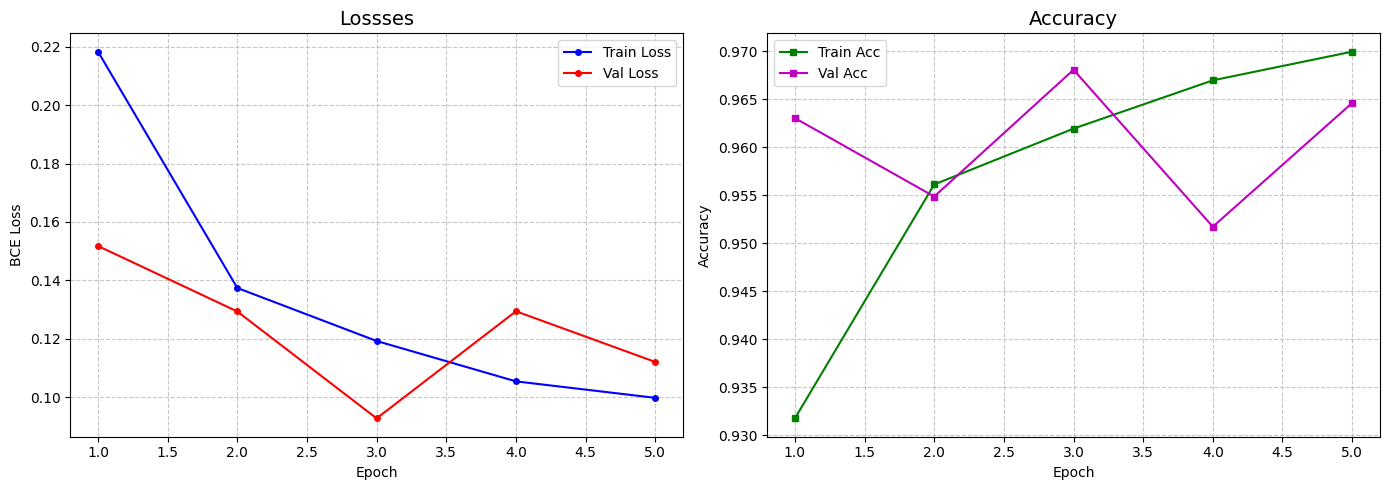

In [14]:
plot_base_model({
    'train_loss': train_losses, 'val_loss': val_lossses,
    'train_acc': trian_accs, 'val_acc': val_accs
    })

# Varying Mel nums

In [15]:
results = {}
# Эксперимент с n_mels
for mels in [20, 40, 80]:
  print(f'=========== Mels={mels} ===========')
  model = BinaryAudioCNN(n_mels=mels, groups=1).to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

  params = model.count_parameters()
  flops = model.get_flops()
  model, train_losses, val_lossses, trian_accs, val_accs, avg_epoch_dur = training_model(
    model=model, train_loader=train_loader, val_loader=valid_loader, epochs=5,
    batch_size=batch_size, device=device
    )
  results[mels] = {'n_mels': mels, 'params': params, 'flops': flops,
                  'train_losses': train_losses, 'val_lossses': val_lossses,
                  'trian_accs': trian_accs, 'val_accs': val_accs,
                  'test_acc': testing_model(model)}

=========== Mels=20 ===========
Epoch 1/5:


  0%|          | 0/199 [00:00<?, ?it/s]

Train loss=0.2132, Train accuracy=92.97%
Valid loss=0.1216, Valid accuracy=96.37%
Epoch 2/5:


  0%|          | 0/199 [00:00<?, ?it/s]

Train loss=0.1282, Train accuracy=95.78%
Valid loss=0.1067, Valid accuracy=96.49%
Epoch 3/5:


...

Train loss=0.1222, Train accuracy=96.23%
Valid loss=0.1070, Valid accuracy=97.00%
Epoch 4/5:


  0%|          | 0/199 [00:00<?, ?it/s]

Train loss=0.1109, Train accuracy=96.38%
Valid loss=0.1777, Valid accuracy=93.19%
Epoch 5/5:


  0%|          | 0/199 [00:00<?, ?it/s]

Train loss=0.1039, Train accuracy=96.59%
Valid loss=0.0993, Valid accuracy=96.74%
Test accuracy=96.74%


In [45]:
def plot_mels_comparison(mels_results):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    for n_mels, hist in mels_results.items():
        plt.plot(hist['train_losses'], label=f'n_mels={n_mels}')
    plt.title('Train Losses', fontsize=12)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    for n_mels, hist in mels_results.items():
        plt.plot(hist['val_accs'], label=f'n_mels={n_mels}')
    plt.title('Val Accuracy', fontsize=12)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

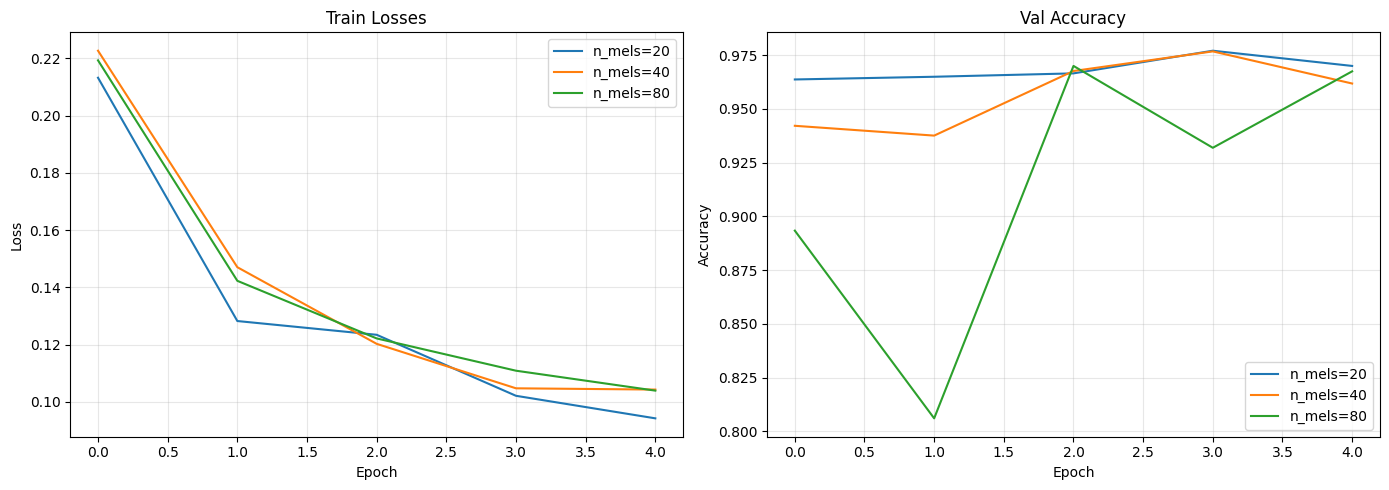

In [46]:
plot_mels_comparison(results)

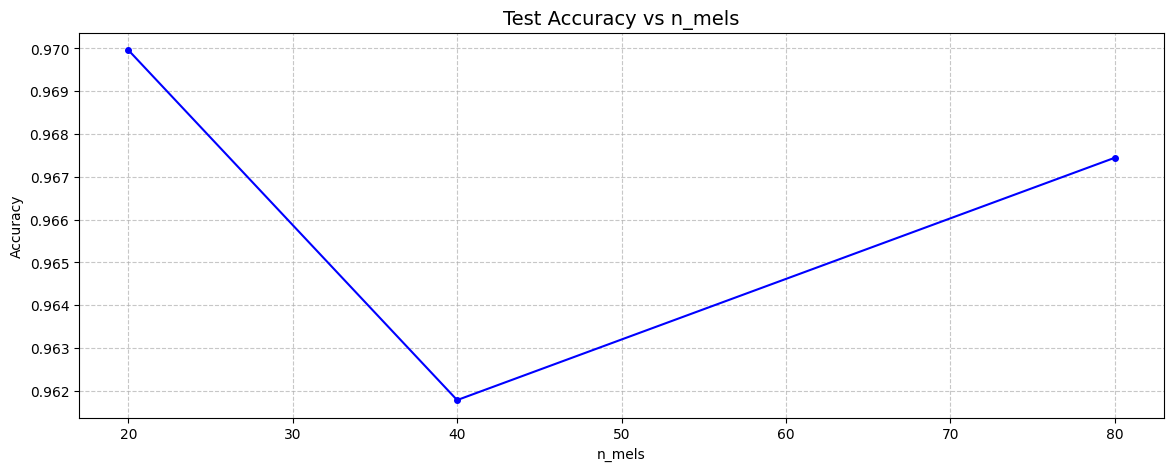

In [47]:
plt.figure(figsize=(14, 5))

plt.plot([20, 40, 80], [test_acc['test_acc'] for _, test_acc in results.items()], 'b-o', markersize=4)
plt.title('Test Accuracy vs n_mels', fontsize=14)
plt.xlabel('n_mels')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show();

# Varying Group nums

## n_mels = 80

In [55]:
# Эксперимент с groups (при n_mels=80)
results_groups = {}
for g in [2, 4, 8]:
  start_time = time.time()
  print(f'=========== groups={g} ===========')
  model = BinaryAudioCNN(n_mels=80, groups=g).to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
  params = model.count_parameters()
  flops = model.get_flops()
  model, train_losses, val_lossses, trian_accs, val_accs, avg_epoch_dur = training_model(
    model=model, train_loader=train_loader, val_loader=valid_loader, epochs=5,
    batch_size=batch_size, device=device
    )
  end_time = time.time()
  epoch_dur = end_time - start_time
  results_groups[g] = {
      'g': g, 'params': params, 'flops': flops,
      'avg_epoch_duration': avg_epoch_dur,'train_losses': train_losses,
      'val_lossses': val_lossses, 'trian_accs': trian_accs,
      'val_accs': val_accs, 'test_acc': testing_model(model)}

=========== groups=2 ===========
Epoch 1/5:


  0%|          | 0/199 [00:00<?, ?it/s]

Train loss=0.2283, Train accuracy=92.07%
Valid loss=0.1470, Valid accuracy=94.87%
Epoch 2/5:


  0%|          | 0/199 [00:00<?, ?it/s]

Train loss=0.1532, Train accuracy=94.92%
Valid loss=0.1242, Valid accuracy=95.77%
Epoch 3/5:


...

Train loss=0.1354, Train accuracy=95.20%
Valid loss=0.1227, Valid accuracy=96.04%
Epoch 4/5:


  0%|          | 0/199 [00:00<?, ?it/s]

Train loss=0.1306, Train accuracy=95.53%
Valid loss=0.1090, Valid accuracy=96.57%
Epoch 5/5:


  0%|          | 0/199 [00:00<?, ?it/s]

Train loss=0.1141, Train accuracy=96.13%
Valid loss=0.1071, Valid accuracy=96.29%
Test accuracy=96.29%


In [76]:
def plot_groups_comparison(groups_results):

    groups = list(groups_results.keys())
    params = [groups_results[g]['params'] for g in groups]
    avg_times = [groups_results[g]['avg_epoch_duration'] for g in groups]
    flops_ = [groups_results[g]['flops'] for g in groups]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Groups param')
    ax1.set_ylabel('Model params count', color=color)
    ax1.bar(groups, params, color=color, alpha=0.3, label='Params')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:red'
    # ax2.set_ylabel('Epoch time', color=color)
    ax2.plot(groups, avg_times, color=color, marker='D', linewidth=2, label='Avg Epoch Time')
    ax2.tick_params(axis='y', labelcolor=color)
    plt.legend()

    ax2 = ax1.twinx()
    color = 'tab:green'
    ax2.plot(groups, flops_, color=color, marker='D', linewidth=2, label='FLOPs')
    ax2.tick_params(axis='y', labelcolor=color)
    plt.legend()
    plt.title('n_groups vs time vs flops', fontsize=14)
    fig.tight_layout()
    plt.show()

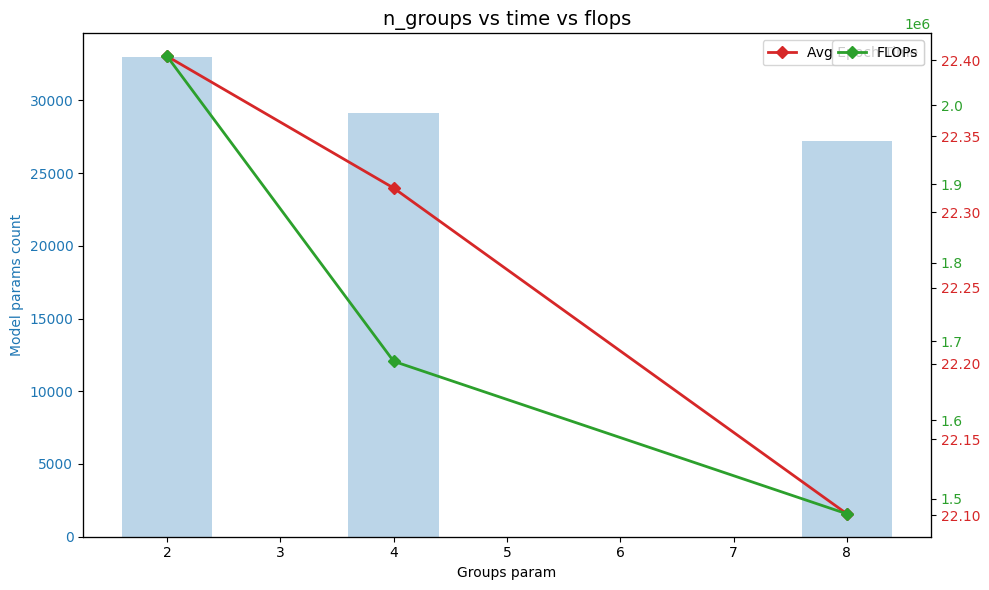

In [77]:
plot_groups_comparison(results_groups)

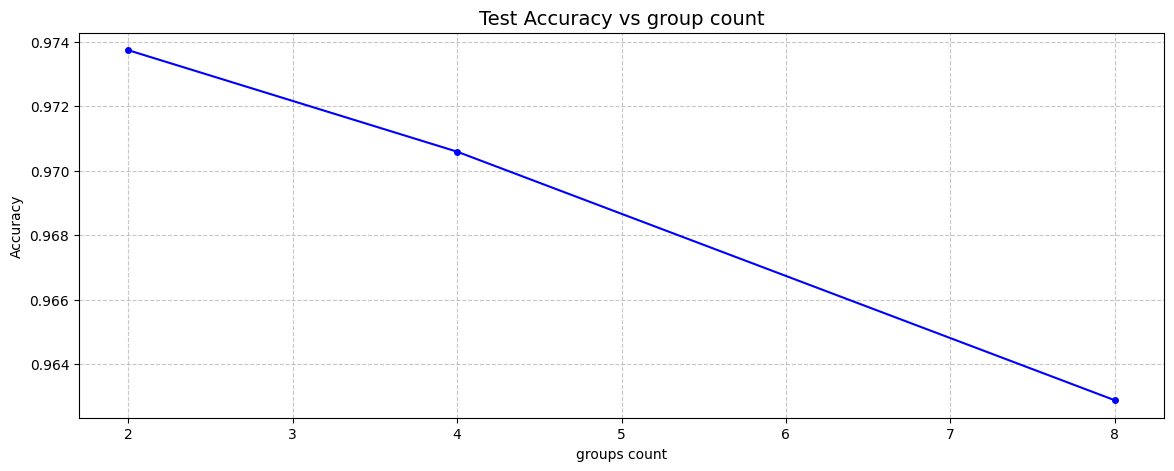

In [60]:
plt.figure(figsize=(14, 5))

plt.plot([2, 4, 8], [test_acc['test_acc'] for _, test_acc in results_groups.items()], 'b-o', markersize=4)
plt.title('Test Accuracy vs group count', fontsize=14)
plt.xlabel('groups count')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show();